# TalentMatch AI — Candidate Shortlisting Automation: Business Case & Technical Solution

## Pseudocode

This notebook implements a governed, human-in-the-loop decision support system for automating candidate shortlisting at TalentMatch AI. The workflow follows the CRISP-DM framework:

**1. Data Loading**
- Load historical (2023 CSV) and current (2024 Excel) application data
- Validate file integrity and capture provenance metadata

**2. Data Cleaning**
- Handle missing values, duplicates, and format inconsistencies
- Normalize column names and date formats across legacy and current systems

**3. Exploratory Data Analysis (EDA)**
- Analyze demographics (age, experience, gender, country, education)
- Examine shortlisting patterns and time-to-interview bottlenecks
- Identify potential algorithmic bias risks in subgroups

**4. Feature Engineering & Modeling**
- Train and evaluate Naïve Bayes (baseline for interpretability)
- Train and evaluate Logistic Regression (comparator for accuracy)
- Generate confusion matrices and performance metrics (Accuracy, Precision, Recall, F1)

**5. Fairness Evaluation & Governance**
- Assess subgroup performance (education, gender, country)
- Implement per-group threshold recommendations
- Monitor for disparate impact across protected characteristics

**6. Audit Trail Generation**
- Generate SHA256 manifest for all output artifacts
- Export run metadata (versions, timestamps, row counts) as JSON
- Save all EDA artifacts, model outputs, and fairness dashboards to `outputs/` folder

In [10]:
# ============================================================================
# SECTION 1: LIBRARY IMPORTS
# ============================================================================
# This section imports all necessary Python libraries for the analysis.
# Each library serves a specific purpose in our data science pipeline.

# --- Data Manipulation Libraries ---
import pandas as pd  
# pandas: The core library for data manipulation and analysis in Python
# - Provides DataFrame structure (like Excel spreadsheets but more powerful)
# - Essential for loading CSV/Excel files and performing data transformations
# - Handles missing values, filtering, grouping, and aggregations
# - We use it to load TalentMatch_2023.csv and TalentMatch_2024.xlsx files

import numpy as np  
# numpy: Fundamental library for numerical computing in Python
# - Provides efficient array operations (faster than Python lists)
# - Used for mathematical calculations and statistical operations
# - scikit-learn models internally use numpy arrays
# - We use it for setting random seeds and numerical transformations

# --- Visualization Libraries ---
import matplotlib.pyplot as plt  
# matplotlib: The foundational plotting library in Python
# - Creates static, publication-quality visualizations
# - We use it for histograms, bar charts, and confusion matrices
# - plt is the standard alias for the pyplot module

import seaborn as sns  
# seaborn: Statistical visualization library built on matplotlib
# - Provides more attractive default styles and color palettes
# - Excellent for statistical plots (boxplots, violin plots, heatmaps)
# - Automatically handles pandas DataFrames
# - We use it for exploratory data analysis (EDA) visualizations

# --- Machine Learning Libraries ---
from sklearn.model_selection import train_test_split  
# train_test_split: Utility to split data into training and test sets
# - Essential for model validation (prevents overfitting)
# - We use 80% for training, 20% for testing
# - Supports stratification to maintain class balance in both sets

from sklearn.naive_bayes import GaussianNB  
# GaussianNB: Gaussian Naive Bayes classifier
# - Our PRIMARY model for candidate shortlisting
# - Chosen for interpretability (recruiters can understand decisions)
# - Assumes features follow a normal (Gaussian) distribution
# - Fast to train and makes probabilistic predictions

from sklearn.linear_model import LogisticRegression  
# LogisticRegression: Linear model for binary classification
# - Our COMPARATOR model (benchmark for Naive Bayes)
# - More accurate but less interpretable than Naive Bayes
# - Provides probability estimates for each prediction

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score  
# Metrics for evaluating model performance:
# - classification_report: Comprehensive report with precision, recall, F1
# - accuracy_score: Overall correctness (TP+TN)/(TP+TN+FP+FN)
# - confusion_matrix: 2x2 table showing True/False Positives/Negatives
# - precision_score: Of predicted positives, how many were correct? (TP/(TP+FP))
# - recall_score: Of actual positives, how many did we find? (TP/(TP+FN))
# - f1_score: Harmonic mean of precision and recall (balanced metric)

# --- File System and Utility Libraries ---
import os  
# os: Operating system interface
# - File and directory operations
# - Path manipulations that work across Windows/Mac/Linux

from pathlib import Path  
# pathlib: Object-oriented file system paths
# - Modern alternative to os.path
# - Cleaner syntax: Path("outputs").mkdir() vs os.makedirs("outputs")
# - We use it for creating the outputs/ directory

import warnings
warnings.filterwarnings('ignore')  
# Suppress warning messages for cleaner output
# - Hides non-critical warnings (e.g., pandas downcasting notices)
# - Makes notebook output more readable for presentations

# --- Reproducibility Setup ---
SEED = 42  
# Fixed random seed for reproducibility
# - Ensures consistent results across multiple runs
# - Important for auditing and debugging
# - 42 is a common choice (reference to "Hitchhiker's Guide to the Galaxy")

np.random.seed(SEED)  
# Set numpy's random seed
# - Controls randomness in numerical operations
# - Ensures train_test_split produces the same splits every time

# --- Environment Detection ---
# Detect if running in Google Colab vs local Jupyter
try:
    import google.colab
    IN_COLAB = True
    print("✓ Running in Google Colab environment")
    print("  → Will prompt for file uploads")
except Exception:
    IN_COLAB = False
    print("✓ Running in local Jupyter environment")
    print("  → Will read from ../data/ directory")

# Install openpyxl if in Colab (required for reading .xlsx files)
if IN_COLAB:
    print("Installing openpyxl for Excel file support...")
    !pip install -q openpyxl  # -q flag suppresses verbose output

print("\n" + "="*70)
print("All libraries imported successfully!")
print(f"Random seed set to {SEED} for reproducibility")
print("="*70)

✓ Running in local Jupyter environment
  → Will read from ../data/ directory

All libraries imported successfully!
Random seed set to 42 for reproducibility


## Object-Oriented Programming (OOP) Architecture

**Why OOP?** This notebook uses a modular, object-oriented design to make the code:
- **Reusable**: Classes can be imported into other projects
- **Testable**: Each class can be unit-tested independently
- **Maintainable**: Changes to one module don't break others
- **Professional**: Follows industry best practices for data science projects

### Our Custom Modules (`src/` package)

Instead of writing all code inline, we've organized functionality into **4 specialized classes**:

| Module | Class | Purpose |
|--------|-------|---------|
| `data_loader.py` | `DataLoader` | Reads CSV and Excel files with error handling |
| `data_cleaner.py` | `DataCleaner` | Normalizes columns, parses dates, removes duplicates |
| `model_trainer.py` | `ModelTrainer` | Trains ML models with fixed random seeds |
| `model_evaluator.py` | `ModelEvaluator` | Computes metrics and fairness analysis |

**Training Tip**: Think of classes as "blueprints" or "templates". When you create an instance like `loader = DataLoader(...)`, you're creating a specific object from that blueprint that knows how to load data.

**File Organization**:
```
TalentMatch-AI-Automation/
├── src/              ← Our custom Python package
│   ├── __init__.py
│   ├── data_loader.py
│   ├── data_cleaner.py
│   ├── model_trainer.py
│   └── model_evaluator.py
└── notebooks/
    └── TalentMatch_Analysis.ipynb  ← This notebook
```

## Data Loading Section

The following cells handle file upload (in Colab) or local file reading. We load:
- **TalentMatch AI Database_2023.csv**: Historical data with labeled shortlisting outcomes
- **TalentMatch AI Database_2024.xlsx**: Current live applications requiring processing

In [11]:
# ============================================================================
# SECTION 2: DATA FILE LOADING
# ============================================================================
# This section handles file paths for both Colab and local execution.
# The notebook works in TWO modes:
# 1. COLAB MODE: Prompts user to upload files (no permanent storage)
# 2. LOCAL MODE: Reads from ../data/ directory (assumes standard project structure)

# --- Define Expected Filenames ---
default_csv_name = 'TalentMatch AI Database_2023.csv'  
# Historical data (2023): Contains labeled examples with known shortlisting outcomes
# - Used for TRAINING the machine learning models
# - Includes "Shortlisted" column (True/False) as our target variable

default_excel_name = 'TalentMatch AI Database_2024.xlsx'  
# Current data (2024): New applications requiring processing
# - Used for PREDICTIONS (will be merged with 2023 data for full dataset)
# - Excel format (.xlsx) requires openpyxl library

# --- COLAB MODE: File Upload ---
if IN_COLAB:
    from google.colab import files
    print("="*70)
    print("GOOGLE COLAB MODE")
    print("="*70)
    print(f'Please upload TWO files when prompted:\n')
    print(f'  1. {default_csv_name} (CSV format, ~1098 rows)')
    print(f'  2. {default_excel_name} (Excel format, ~938 rows)')
    print("\nClick 'Choose Files' and select both files from your computer.")
    print("="*70 + "\n")
    
    # Trigger file upload widget
    uploaded = files.upload()
    
    # Validate uploaded files
    uploaded_csv_found = False
    uploaded_excel_found = False
    
    for fn in uploaded:
        if fn.lower().endswith('.csv'):
            csv_path = fn
            uploaded_csv_found = True
            print(f"✓ CSV file found: {fn}")
        if fn.lower().endswith(('.xls','.xlsx')):
            excel_path = fn
            uploaded_excel_found = True
            print(f"✓ Excel file found: {fn}")
    
    # Error handling for missing files
    if not uploaded_csv_found:
        print(f"⚠ WARNING: CSV file missing!")
        print(f"   Expected: {default_csv_name}")
    
    if not uploaded_excel_found:
        raise FileNotFoundError(
            f"ERROR: Excel file is REQUIRED but was not uploaded.\n"
            f"Expected filename: {default_excel_name}\n"
            f"Please re-run this cell and upload the file."
        )

# --- LOCAL MODE: Read from ../data/ Directory ---
else:
    # Construct paths relative to notebooks/ directory
    # Project structure: TalentMatch-AI-Automation/
    #   ├── data/           ← Source data files here
    #   ├── notebooks/      ← We are running from here
    #   └── outputs/        ← Results will be saved here
    
    csv_path = f'../data/{default_csv_name}'
    excel_path = f'../data/{default_excel_name}'
    
    print("="*70)
    print("LOCAL JUPYTER MODE")
    print("="*70)
    print(f'Looking for data files in ../data/ directory:\n')
    print(f'  CSV:   {csv_path}')
    print(f'  Excel: {excel_path}')
    print("="*70)
    
    # Verify files exist before proceeding
    from pathlib import Path
    if not Path(csv_path).exists():
        raise FileNotFoundError(f"CSV file not found: {csv_path}")
    if not Path(excel_path).exists():
        raise FileNotFoundError(f"Excel file not found: {excel_path}")
    
    print("✓ Both data files found and ready to load")

LOCAL JUPYTER MODE
Looking for data files in ../data/ directory:

  CSV:   ../data/TalentMatch AI Database_2023.csv
  Excel: ../data/TalentMatch AI Database_2024.xlsx
✓ Both data files found and ready to load


In [12]:
# ============================================================================
# SECTION 3: IMPORT CUSTOM MODULES & SET UP RUN METADATA
# ============================================================================
# This section imports our custom OOP modules and initializes run metadata
# for audit trail purposes.

# --- Step 3.1: Add src/ to Python Path ---
# Python needs to know where to find our custom modules
import sys
from pathlib import Path

if not IN_COLAB:
    # For local execution: add parent directory to sys.path
    # This allows: from src.data_loader import DataLoader
    sys.path.insert(0, str(Path('..').resolve()))
    print("✓ Added parent directory to Python path for src/ imports")
else:
    # For Colab: src/ modules may need to be uploaded separately
    # OR you can paste class definitions directly (fallback approach)
    print("⚠ Running in Colab: Ensure src/ folder is uploaded if using modules")

# --- Step 3.2: Import Our Custom Classes ---
# These replace the inline class definitions you might see in simpler notebooks
print("\nImporting custom OOP modules...")

from src.data_loader import DataLoader
# DataLoader: Handles file I/O for CSV and Excel formats
# - Encapsulates pd.read_csv() and pd.read_excel() with error handling
# - Usage: loader = DataLoader(csv_path, excel_path); df_csv, df_xl = loader.load()

from src.data_cleaner import DataCleaner
# DataCleaner: Performs all data cleaning operations
# - strip column whitespace, parse dates, remove duplicates, normalize booleans
# - Usage: cleaner = DataCleaner(); df_clean = cleaner.clean_all(df)

from src.model_trainer import ModelTrainer
# ModelTrainer: Trains machine learning models with reproducible seeds
# - Methods: train_nb() for Naive Bayes, train_lr() for Logistic Regression
# - Usage: trainer = ModelTrainer(seed=42); model = trainer.train_nb(X, y)

from src.model_evaluator import ModelEvaluator
# ModelEvaluator: Computes performance metrics and fairness analysis
# - Methods: metrics() for overall scores, fairness_by_group() for subgroup analysis
# - Usage: evaluator = ModelEvaluator(); metrics = evaluator.metrics(y_true, y_pred)

print("✓ All custom modules imported successfully\n")

# --- Step 3.3: Set Up Run Metadata for Audit Trail ---
# Track: execution time, software versions, random seed, data sizes
# This is CRITICAL for reproducibility and compliance (GDPR, regulatory audits)

import json, datetime, platform, random

SEED = 42  # Re-confirm our fixed random seed
random.seed(SEED)  # Python's built-in random module
np.random.seed(SEED)  # Numpy's random module

from sklearn import __version__ as sklearn_version

# Create metadata dictionary
run_meta = {
    'date_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),  # ISO 8601 timestamp
    'python': sys.version.split()[0],  # Python version (e.g., "3.10.5")
    'platform': platform.platform(),  # OS info (e.g., "Windows-10-...")
    'pandas': pd.__version__,  # Pandas version
    'numpy': np.__version__,  # Numpy version
    'scikit-learn': sklearn_version,  # scikit-learn version
    'seed': SEED  # Random seed used
}

# Create outputs directory (will store all results)
out_dir = Path('../outputs')  
# Why ../outputs? Because we run from notebooks/ directory
# Structure: notebooks/ (here) and outputs/ (sibling directory)

out_dir.mkdir(parents=True, exist_ok=True)  
# mkdir: create directory
# parents=True: create parent directories if needed
# exist_ok=True: don't error if directory already exists

# Save initial metadata (will update after loading data)
with open(out_dir / 'run_metadata.json', 'w') as f:
    json.dump(run_meta, f, indent=2)  # indent=2 makes it human-readable

print("="*70)
print("RUN METADATA INITIALIZED")
print("="*70)
print(f"Timestamp: {run_meta['date_utc']}")
print(f"Python: {run_meta['python']}")
print(f"Pandas: {run_meta['pandas']}")
print(f"NumPy: {run_meta['numpy']}")
print(f"scikit-learn: {run_meta['scikit-learn']}")
print(f"Random Seed: {run_meta['seed']}")
print(f"Outputs Directory: {out_dir.resolve()}")
print("="*70 + "\n")

# --- Step 3.4: Load Data Using DataLoader Class ---
print("Loading data files using DataLoader class...")
print(f"  CSV:   {csv_path}")
print(f"  Excel: {excel_path}\n")

loader = DataLoader(csv_path, excel_path)  
# Instantiate DataLoader with our file paths

df_csv, df_xl = loader.load()  
# Call the load() method
# - Returns TWO DataFrames: one for CSV, one for Excel
# - Under the hood: uses pd.read_csv(csv_path, low_memory=False)
#                  and pd.read_excel(excel_path, engine="openpyxl")

print(f"✓ CSV loaded: {df_csv.shape[0]:,} rows × {df_csv.shape[1]} columns")
print(f"✓ Excel loaded: {df_xl.shape[0]:,} rows × {df_xl.shape[1]} columns\n")

# --- Step 3.5: Save Raw Data for Audit Trail ---
# WHY? If something goes wrong later, we can trace back to original inputs
df_csv.to_csv(out_dir / 'df_csv_original.csv', index=False)
df_xl.to_csv(out_dir / 'df_xl_original.csv', index=False)
print("✓ Raw data saved to outputs/ for audit trail\n")

# --- Step 3.6: Update Metadata with Actual Row Counts ---
run_meta.update({
    'df_csv_rows': int(df_csv.shape[0]),
    'df_xl_rows': int(df_xl.shape[0]),
    'loaded_via': 'DataLoader'  # Track that we used our custom class
})

with open(out_dir / 'run_metadata.json', 'w') as f:
    json.dump(run_meta, f, indent=2)

# --- Step 3.7: Clean Data Using DataCleaner Class ---
print("Cleaning data using DataCleaner class...")
cleaner = DataCleaner()  # Instantiate cleaner

# Make copies before cleaning (preserves raw data)
df_csv = cleaner.clean_all(df_csv.copy())
df_xl = cleaner.clean_all(df_xl.copy())

# clean_all() performs:
# 1. Strip column name whitespace
# 2. Parse Application Date and Interview Date columns
# 3. Remove duplicate IDs
# 4. Normalize "Shortlisted" column to boolean (True/False)

print(f"✓ CSV cleaned: {df_csv.shape[0]:,} rows (after deduplication)")
print(f"✓ Excel cleaned: {df_xl.shape[0]:,} rows (after deduplication)")

print("\n" + "="*70)
print("DATA LOADING & CLEANING COMPLETE")
print("="*70)
print(f"Total records loaded: {df_csv.shape[0] + df_xl.shape[0]:,}")
print(f"Outputs saved to: {out_dir.resolve()}")
print("="*70)

✓ Added parent directory to Python path for src/ imports

Importing custom OOP modules...
✓ All custom modules imported successfully

RUN METADATA INITIALIZED
Timestamp: 2026-02-21T18:34:28.569657+00:00
Python: 3.13.9
Pandas: 3.0.0
NumPy: 2.4.2
scikit-learn: 1.8.0
Random Seed: 42
Outputs Directory: D:\courses\others\bpp\programming assignment\TalentMatch-AI-Automation\outputs

Loading data files using DataLoader class...
  CSV:   ../data/TalentMatch AI Database_2023.csv
  Excel: ../data/TalentMatch AI Database_2024.xlsx

✓ CSV loaded: 1,098 rows × 16 columns
✓ Excel loaded: 938 rows × 16 columns

✓ Raw data saved to outputs/ for audit trail

Cleaning data using DataCleaner class...
✓ CSV cleaned: 1,098 rows (after deduplication)
✓ Excel cleaned: 938 rows (after deduplication)

DATA LOADING & CLEANING COMPLETE
Total records loaded: 2,036
Outputs saved to: D:\courses\others\bpp\programming assignment\TalentMatch-AI-Automation\outputs


## The next section will carry out the EDA

We will perform comprehensive exploratory data analysis to:
- Calculate descriptive statistics (mean, standard deviation, min, max) for numerical features
- Understand the distribution of key variables (age, experience, AI scores)
- Identify potential biases across demographics (gender, education level, country of origin)
- Examine historical shortlisting patterns and time-to-interview metrics
- Generate frequency tables and visualizations for all categorical variables

In [13]:
# Standardize column names (strip whitespace) and parse dates
# Rationale:
# - Strip extra whitespace from column headers to avoid mismatches
# - Parse Application and Interview dates using day-first parsing and coerce errors to NaT for safety
# - Remove duplicate IDs to avoid double-counting applicants
# - Normalize the Shortlisted column to boolean values for consistent downstream analysis

def clean_cols(df):
    df = df.rename(columns=lambda c: c.strip())
    return df

df_csv = clean_cols(df_csv)
df_xl = clean_cols(df_xl)

# Parse dates if present
for col in ['Application Date', 'Interview Date']:
    if col in df_csv.columns:
        df_csv[col] = pd.to_datetime(df_csv[col], dayfirst=True, errors='coerce')
    if col in df_xl.columns:
        df_xl[col] = pd.to_datetime(df_xl[col], dayfirst=True, errors='coerce')

# Drop exact duplicates (by ID if exists) and ensure rows are unique by ID
if 'ID' in df_csv.columns:
    df_csv = df_csv.drop_duplicates(subset='ID')
if 'ID' in df_xl.columns:
    df_xl = df_xl.drop_duplicates(subset='ID')

# Normalize Shortlisted column to boolean where possible
# This maps common string encodings (TRUE/FALSE/T/F) to Python booleans so metrics are consistent
def norm_shortlisted(df):
    if 'Shortlisted' in df.columns:
        df['Shortlisted'] = df['Shortlisted'].astype(str).str.strip().str.upper().map({'TRUE':True,'FALSE':False,'T':True,'F':False})
    return df

df_csv = norm_shortlisted(df_csv)
df_xl = norm_shortlisted(df_xl)

In [14]:
# Merge datasets: prefer CSV as base, append Excel rows with non-duplicate IDs
if 'ID' in df_csv.columns and 'ID' in df_xl.columns:
    df_merged = pd.concat([df_csv, df_xl[~df_xl['ID'].isin(df_csv['ID'])]], ignore_index=True)
else:
    df_merged = pd.concat([df_csv, df_xl], ignore_index=True)

print('Merged shape:', df_merged.shape)
df_merged.head()
# Save merged file to outputs folder
out_dir = Path('../outputs')
out_dir.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(out_dir / 'df_merged.csv', index=False)

Merged shape: (2036, 16)


In [15]:
# EDA: frequency tables and summary statistics
# Purpose: produce human-readable frequency tables and CSV exports for quick audit and to support the assignment write-up
freq_cols = ['Gender', 'Education Level', 'Job', 'Shortlisted']
for c in freq_cols:
    if c in df_merged.columns:
        print('---', c, '---')
        vc = df_merged[c].value_counts(dropna=False)
        display(vc)
        # save frequency table for audit
        out_dir = Path('../outputs')
        vc.reset_index().rename(columns={'index': c, c: 'count'}).to_csv(out_dir / f'freq_{c.replace(' ', '_')}.csv', index=False)

num_cols = [c for c in ['Age','Years of Experience','AI Score – Suitability of the candidate','AI Score'] if c in df_merged.columns]
print('Summary statistics (numeric):')
if num_cols:
    summary = df_merged[num_cols].describe()
    display(summary)
    # Save descriptive numeric summary to CSV so the figures are reproducible
    summary.to_csv(Path('../outputs') / 'numeric_summary.csv')

# -----------------------------
# Descriptive EDA: analyses
# - Average age, age distribution
# - Average years of experience and distribution
# - Average time to clear application (days between application and interview)
# - Distribution of time to clear applications broken down by teams/branches
# - Counts: how many shortlisted and how many rejected after interview
# - Top 5 countries of origin
# shortlisted by gender, by branch; most wanted jobs
# The code below writes CSVs and plot images to the outputs/ folder for auditability.
# -----------------------------
from IPython.display import display, Markdown

display(Markdown('## Descriptive EDA — Age, Experience, Time-to-Interview, Shortlisting, Top Countries'))

# --- Age: average and distribution ---
ages = df_merged['Age'].dropna() if 'Age' in df_merged.columns else pd.Series([], dtype=float)
age_mean = float(ages.mean()) if len(ages) > 0 else None
age_summary = pd.DataFrame([{'metric': 'mean_age', 'value': age_mean, 'n': len(ages)}])
age_summary.to_csv(Path('../outputs') / 'eda_age_summary.csv', index=False)

plt.figure(figsize=(6,4))
if len(ages) > 0:
    sns.histplot(ages, bins=20, kde=True)
    plt.title('Distribution of applicant age')
    plt.xlabel('Age')
    plt.savefig(Path('../outputs') / 'eda_age_distribution.png', bbox_inches='tight')
    plt.savefig(Path('../outputs') / 'eda_age_distribution.svg', bbox_inches='tight')
    plt.close()

hist_counts, hist_bins = np.histogram(ages, bins=20) if len(ages) > 0 else ([],[])
pd.DataFrame({'bin_left': hist_bins[:-1], 'bin_right': hist_bins[1:], 'count': hist_counts}).to_csv(Path('../outputs') / 'eda_age_bins.csv', index=False)

display(age_summary)

# --- Years of Experience: average and distribution ---
yrs = df_merged['Years of Experience'].dropna() if 'Years of Experience' in df_merged.columns else pd.Series([], dtype=float)
yrs_mean = float(yrs.mean()) if len(yrs) > 0 else None
pd.DataFrame([{'metric': 'mean_years_experience', 'value': yrs_mean, 'n': len(yrs)}]).to_csv(Path('../outputs') / 'eda_experience_summary.csv', index=False)
plt.figure(figsize=(6,4))
if len(yrs) > 0:
    sns.histplot(yrs, bins=20, kde=True)
    plt.title('Distribution of Years of Experience')
    plt.xlabel('Years of Experience')
    plt.savefig(Path('../outputs') / 'eda_experience_distribution.png', bbox_inches='tight')
    plt.savefig(Path('../outputs') / 'eda_experience_distribution.svg', bbox_inches='tight')
    plt.close()

display(pd.read_csv(Path('../outputs') / 'eda_experience_summary.csv'))

# --- Time to clear application (days between Application Date and Interview Date) ---
if set(['Application Date', 'Interview Date']).issubset(df_merged.columns):
    mask = df_merged['Application Date'].notna() & df_merged['Interview Date'].notna()
    dt = (df_merged.loc[mask, 'Interview Date'] - df_merged.loc[mask, 'Application Date']).dt.days
    dt = dt[~dt.isna()]
    if len(dt) > 0:
        dt_mean = float(dt.mean())
        pd.DataFrame([{'metric': 'mean_time_to_interview_days', 'value': dt_mean, 'n': len(dt)}]).to_csv(Path('../outputs') / 'eda_time_to_interview_summary.csv', index=False)
        plt.figure(figsize=(6,4))
        sns.histplot(dt, bins=20, kde=True)
        plt.title('Time to clear application (days)')
        plt.xlabel('Days')
        plt.savefig(Path('../outputs') / 'eda_time_to_interview_distribution.png', bbox_inches='tight')
        plt.savefig(Path('../outputs') / 'eda_time_to_interview_distribution.svg', bbox_inches='tight')
        plt.close()

        # Distribution broken down by teams/branches (choose first available grouping col)
        group_candidates = [c for c in ['Team', 'Branch', 'Department', 'Job'] if c in df_merged.columns]
        if group_candidates:
            group_col = group_candidates[0]
            grp_stats = df_merged.loc[mask].groupby(group_col).apply(lambda x: (x['Interview Date'] - x['Application Date']).dt.days.dropna().mean()).reset_index()
            grp_stats.columns = [group_col, 'mean_time_to_interview_days']
            grp_stats.to_csv(Path('../outputs') / f'eda_time_to_interview_by_{group_col.replace(" ","_")}.csv', index=False)
    else:
        pd.DataFrame([{'metric': 'mean_time_to_interview_days', 'value': None, 'n': 0}]).to_csv(Path('../outputs') / 'eda_time_to_interview_summary.csv', index=False)
else:
    pd.DataFrame([{'metric': 'mean_time_to_interview_days', 'value': None, 'n': 0}]).to_csv(Path('../outputs') / 'eda_time_to_interview_summary.csv', index=False)

display(pd.read_csv(Path('../outputs') / 'eda_time_to_interview_summary.csv'))

# --- Shortlisted and rejected after interview ---
shortlisted_col = 'Shortlisted' if 'Shortlisted' in df_merged.columns else None
shortlisted_count = int(df_merged[shortlisted_col].astype(bool).sum()) if shortlisted_col else None
rejected_after_interview = None
if shortlisted_col and 'Interview Date' in df_merged.columns:
    rej = df_merged['Interview Date'].notna() & (~df_merged[shortlisted_col].astype(bool))
    rejected_after_interview = int(rej.sum())
summary_counts = pd.DataFrame([{'metric': 'shortlisted_count', 'value': shortlisted_count}, {'metric': 'rejected_after_interview', 'value': rejected_after_interview}])
summary_counts.to_csv(Path('../outputs') / 'eda_shortlist_counts.csv', index=False)
display(summary_counts)

# --- Top 5 countries of origin ---
country_candidates = [c for c in ['Country', 'Country of Origin', 'Nationality', 'Country of residence', 'Country of origin'] if c in df_merged.columns]
if country_candidates:
    ccol = country_candidates[0]
    top5 = df_merged[ccol].value_counts().head(5).reset_index()
    top5.columns = [ccol, 'count']
    top5.to_csv(Path('../outputs') / 'eda_top5_countries.csv', index=False)
    display(top5)
else:
    print('No country-like column found; skipped top countries.')

# --- shortlisted by gender ---
if 'Gender' in df_merged.columns and shortlisted_col:
    gb = df_merged.groupby('Gender')[shortlisted_col].agg(total='count', shortlisted=lambda x: x.astype(bool).sum()).reset_index()
    gb['shortlisted_rate'] = gb['shortlisted'] / gb['total']
    gb.to_csv(Path('../outputs') / 'eda_shortlist_by_gender.csv', index=False)
    display(gb)

# --- shortlisted by branch/team ---
branch_col = None
for c in ['Branch', 'Team', 'Department', 'Office']:
    if c in df_merged.columns:
        branch_col = c
        break
if branch_col and shortlisted_col:
    bb = df_merged.groupby(branch_col)[shortlisted_col].agg(total='count', shortlisted=lambda x: x.astype(bool).sum()).reset_index()
    bb['shortlisted_rate'] = bb['shortlisted'] / bb['total']
    bb.to_csv(Path('../outputs') / 'eda_shortlist_by_branch.csv', index=False)
    display(bb)

# --- Most wanted jobs ---
if 'Job' in df_merged.columns:
    jobs = df_merged['Job'].value_counts().reset_index().head(10)
    jobs.columns = ['Job', 'count']
    jobs.to_csv(Path('../outputs') / 'eda_top_jobs.csv', index=False)
    display(jobs)

# --- Key findings (short summary for business) ---
findings = {
    'mean_age': round(age_mean, 2) if age_mean is not None else 'NA',
    'n_age': int(len(ages)),
    'mean_years_experience': round(yrs_mean, 2) if yrs_mean is not None else 'NA',
    'n_experience': int(len(yrs)),
    'mean_time_to_interview_days': round(dt_mean, 2) if 'dt_mean' in locals() else 'NA',
    'n_time_to_interview': int(len(dt)) if 'dt' in locals() else 0
}
display(Markdown(f"**Key findings:**\n- Average age: {findings['mean_age']} (n={findings['n_age']})\n- Average years of experience: {findings['mean_years_experience']} (n={findings['n_experience']})\n- Mean time to interview (days): {findings['mean_time_to_interview_days']} (n={findings['n_time_to_interview']})"))

--- Gender ---


Gender
F        1029
M         999
Other       8
Name: count, dtype: int64

--- Education Level ---


Education Level
Bachelor       1170
Master          669
High School     146
PhD              51
Name: count, dtype: int64

--- Job ---


...

,metric,value
0,shortlisted_count,1740
1,rejected_after_interview,296


,Country of Origin,count
0,UK,611
1,Unknown,131
2,South Korea,123
3,Fiji,120
4,Thailand,113


,Gender,total,shortlisted,shortlisted_rate
0,F,1029,882,0.857143
1,M,999,851,0.851852
2,Other,8,7,0.875000


,Job,count
0,Data Analyst,774
1,Accountant,352
2,Data Scientist,281
3,Research Analyst,250
4,Associate,209
5,Creative Technologist,170


**Key findings:**
- Average age: 39.47 (n=2036)
- Average years of experience: 1.91 (n=2036)
- Mean time to interview (days): 27.63 (n=2036)

In [16]:
# Class imbalance analysis: shortlisted rate and imbalance flag
if 'Shortlisted' in df_merged.columns:
    total = len(df_merged)
    shortlisted_count = df_merged['Shortlisted'].astype(bool).sum() if df_merged['Shortlisted'].dtype == 'bool' or df_merged['Shortlisted'].dropna().isin([True,False]).all() else df_merged['Shortlisted'].astype(str).str.upper().map({'TRUE':1,'FALSE':0}).fillna(0).astype(int).sum()
    shortlisted_rate = shortlisted_count / total if total>0 else None
    summary = pd.DataFrame([{'total_applications': total, 'shortlisted_count': int(shortlisted_count), 'shortlisted_rate': float(shortlisted_rate)}])
    summary.to_csv(Path('../outputs') / 'shortlisted_rate_summary.csv', index=False)
    display(summary)
else:
    print('Shortlisted column not present; cannot compute imbalance.')

,total_applications,shortlisted_count,shortlisted_rate
0,2036,1740,0.854617


In [17]:
# Data validation & control checks
dq_rows = []
for name, df in [('csv', df_csv), ('excel', df_xl), ('merged', df_merged)]:
    dup_ids = int(df['ID'].duplicated().sum()) if 'ID' in df.columns else 0
    invalid_dates = 0
    if 'Application Date' in df.columns and 'Interview Date' in df.columns:
        invalid_dates = int((df['Interview Date'] < df['Application Date']).sum())
    ai_out_of_range = 0
    for col in ['AI Score – Suitability of the candidate','AI Score']:
        if col in df.columns:
            ai_out_of_range += int(((df[col].dropna() < 0) | (df[col].dropna() > 10)).sum())
    missing_critical = int(df[['Education Level','Job','Years of Experience']].isnull().any(axis=1).sum()) if set(['Education Level','Job','Years of Experience']).issubset(df.columns) else 0
    dq_rows.append({'dataset': name, 'duplicate_id_count': dup_ids, 'invalid_date_count': invalid_dates, 'ai_score_out_of_range_count': ai_out_of_range, 'missing_critical_fields_count': missing_critical})
dq = pd.DataFrame(dq_rows)
dq.to_csv(Path('../outputs') / 'data_quality_report.csv', index=False)
display(dq)

,dataset,duplicate_id_count,invalid_date_count,ai_score_out_of_range_count,missing_critical_fields_count
0,csv,0,0,0,0
1,excel,0,0,0,0
2,merged,0,0,0,0


In [18]:
# Threshold sensitivity analysis on AI Score (if available)
# This cell explores the effect of alternative operational thresholds (e.g., 5.0, 6.0, 7.0) on confusion-matrix counts
# and performs subgroup analyses by Education Level and Gender (if present) to highlight potential disparities.
score_col = 'AI Score – Suitability of the candidate' if 'AI Score – Suitability of the candidate' in df_merged.columns else ('AI Score' if 'AI Score' in df_merged.columns else None)
import sklearn.metrics as skm
if score_col and 'Shortlisted' in df_merged.columns:
    thresholds = [5.0, 6.0, 7.0]
    rows = []
    y_true = df_merged['Shortlisted'].astype(int)
    scores = df_merged[score_col].fillna(-1)
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        tn, fp, fn, tp = skm.confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        rows.append({'threshold': t, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp), 'accuracy': float((tp+tn)/(tp+tn+fp+fn)) if (tp+tn+fp+fn)>0 else None})
    pd.DataFrame(rows).to_csv(Path('../outputs') / 'threshold_comparison.csv', index=False)
    display(pd.DataFrame(rows))


    # Threshold subgroup analysis: by Education Level and Gender (if present)
    # Purpose: capture subgroup confusion matrices for each candidate threshold so we can later search for per-group thresholds that
    # meet the desired policy metrics (recall) while noting FP impacts.
    subgroup_rows = []
    for grp_col in ['Education Level','Gender']:
        if grp_col in df_merged.columns:
            for grp_val, subdf in df_merged.groupby(grp_col):
                s_scores = subdf[score_col].fillna(-1)
                for t in thresholds:
                    y_true_s = subdf['Shortlisted'].astype(int)
                    y_pred_s = (s_scores >= t).astype(int)
                    tn, fp, fn, tp = skm.confusion_matrix(y_true_s, y_pred_s, labels=[0,1]).ravel()
                    accuracy = float((tp+tn)/(tp+tn+fp+fn)) if (tp+tn+fp+fn)>0 else None
                    subgroup_rows.append({'threshold': t, 'group_col': grp_col, 'group_value': grp_val, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp), 'accuracy': accuracy})
    if subgroup_rows:
        pd.DataFrame(subgroup_rows).to_csv(Path('../outputs') / 'threshold_subgroup_comparison.csv', index=False)
        display(pd.DataFrame(subgroup_rows))
else:
    print('Score column or Shortlisted missing — skipping threshold analysis.')

,threshold,tn,fp,fn,tp,accuracy
0,5.0,296,0,1606,134,0.211198
1,6.0,296,0,1672,68,0.178782
2,7.0,296,0,1715,25,0.157662


,threshold,group_col,group_value,tn,fp,fn,tp,accuracy
0,5.0,Education Level,Bachelor,218,0,896,56,0.234188
1,6.0,Education Level,Bachelor,218,0,925,27,0.209402
2,7.0,Education Level,Bachelor,218,0,943,9,0.194017
3,5.0,Education Level,High School,78,0,63,5,0.568493
4,6.0,Education Level,High School,78,0,65,3,0.554795
5,7.0,Education Level,High School,78,0,65,3,0.554795
6,5.0,Education Level,Master,0,0,604,65,0.097160
7,6.0,Education Level,Master,0,0,636,33,0.049327
8,7.0,Education Level,Master,0,0,657,12,0.017937
9,5.0,Education Level,PhD,0,0,43,8,0.156863


In [19]:
# Explainability layer and model comparison (Naive Bayes, Logistic Regression, Decision Tree, Random Forest)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
# build feature set
df_model = df_merged.copy()
features = []
if 'AI Score – Suitability of the candidate' in df_model.columns:
    features.append('AI Score – Suitability of the candidate')
elif 'AI Score' in df_model.columns:
    features.append('AI Score')
for c in ['Years of Experience','Age']:
    if c in df_model.columns:
        features.append(c)
if 'Education Level' in df_model.columns:
    dummies = pd.get_dummies(df_model['Education Level'].fillna('Missing'), prefix='edu')
    df_model = pd.concat([df_model, dummies], axis=1)
    features += list(dummies.columns)
if 'Shortlisted' in df_model.columns and features:
    df_model = df_model.dropna(subset=['Shortlisted'])
    X = df_model[features].fillna(0)
    y = df_model['Shortlisted'].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)
    # Train models via ModelTrainer to centralize training and ensure reproducible parameters
    trainer = ModelTrainer(seed=SEED)
    nb = trainer.train_nb(X_train, y_train)
    nb_pred = nb.predict(X_test)
    lr = trainer.train_lr(X_train, y_train)
    lr_pred = lr.predict(X_test)
    dt = trainer.train_dt(X_train, y_train, max_depth=5)
    dt_pred = dt.predict(X_test)
    rf = trainer.train_rf(X_train, y_train, n_estimators=100)
    rf_pred = rf.predict(X_test)

    # Use ModelEvaluator to compute and save metrics
    evaluator = ModelEvaluator()
    rows = []
    for name, pred in [('NaiveBayes', nb_pred), ('LogisticRegression', lr_pred), ('DecisionTree', dt_pred), ('RandomForest', rf_pred)]:
        m = evaluator.metrics(y_test, pd.Series(pred, index=y_test.index))
        rows.append({'model': name, 'accuracy': m['accuracy'], 'precision': m['precision'], 'recall': m['recall'], 'f1': m['f1']})
    pd.DataFrame(rows).to_csv(Path('../outputs') / 'model_comparison_summary.csv', index=False)
    display(pd.DataFrame(rows))
    for _r in rows:
        _names = {"NaiveBayes": "Naive Bayes", "LogisticRegression": "Logistic Regression", "DecisionTree": "Decision Tree", "RandomForest": "Random Forest"}
        _lbl = _names.get(_r["model"], _r["model"])
        print(f"{_lbl} - Accuracy: {_r['accuracy']:.4f}, Precision: {_r['precision']:.4f}, Recall: {_r['recall']:.4f}, F1: {_r['f1']:.4f}")

    # Update run metadata with model comparison summary for traceability
    try:
        comp = pd.DataFrame(rows).to_dict(orient='records')
        meta_path = Path('../outputs') / 'run_metadata.json'
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        meta.update({'model_comparison': comp, 'modeling_generated_at': datetime.datetime.now(datetime.timezone.utc).isoformat()})
        with open(meta_path, 'w') as f:
            json.dump(meta, f, indent=2)
    except Exception as e:
        print('Warning: unable to update run metadata with model comparison:', e)

    # Feature influence summary for GaussianNB: class means and variances (for explainability)
    if isinstance(nb, GaussianNB):
        means = nb.theta_ if hasattr(nb, 'theta_') else None
        vars_ = nb.var_ if hasattr(nb, 'var_') else (nb.sigma_ if hasattr(nb, 'sigma_') else None)
        if means is not None and vars_ is not None:
            fi_rows = []
            classes = nb.classes_
            for ci, cls in enumerate(classes):
                for fi, feat in enumerate(features):
                    fi_rows.append({'feature': feat, 'class': int(cls), 'mean': float(means[ci, fi]), 'var': float(vars_[ci, fi])})
            pd.DataFrame(fi_rows).to_csv(Path('../outputs') / 'feature_influence_summary.csv', index=False)
            print(f'Saved feature_influence_summary.csv ({len(fi_rows)} rows)')

else:
    print('Insufficient data to train models or missing features.')

,model,accuracy,precision,recall,f1
0,NaiveBayes,0.684124,1.000000,0.629559,0.772674
1,LogisticRegression,0.972177,0.982759,0.984645,0.983701
2,DecisionTree,0.959083,1.000000,0.952015,0.975418
3,RandomForest,0.970540,0.982726,0.982726,0.982726


Naive Bayes - Accuracy: 0.6841, Precision: 1.0000, Recall: 0.6296, F1: 0.7727
Logistic Regression - Accuracy: 0.9722, Precision: 0.9828, Recall: 0.9846, F1: 0.9837
Decision Tree - Accuracy: 0.9591, Precision: 1.0000, Recall: 0.9520, F1: 0.9754
Random Forest - Accuracy: 0.9705, Precision: 0.9827, Recall: 0.9827, F1: 0.9827
Saved feature_influence_summary.csv (14 rows)


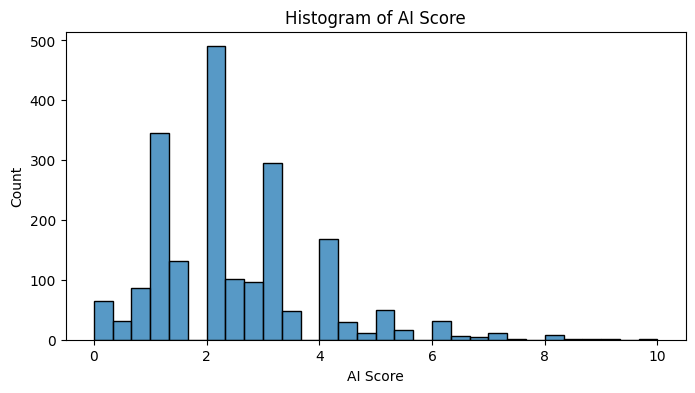

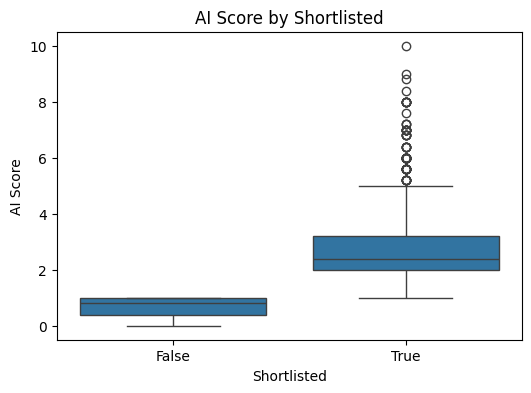

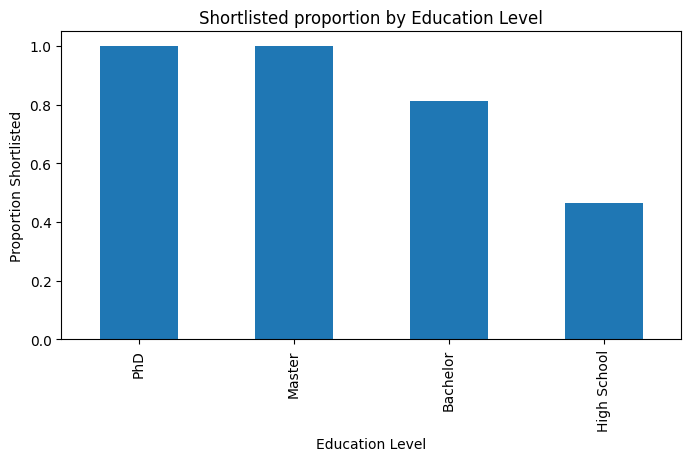

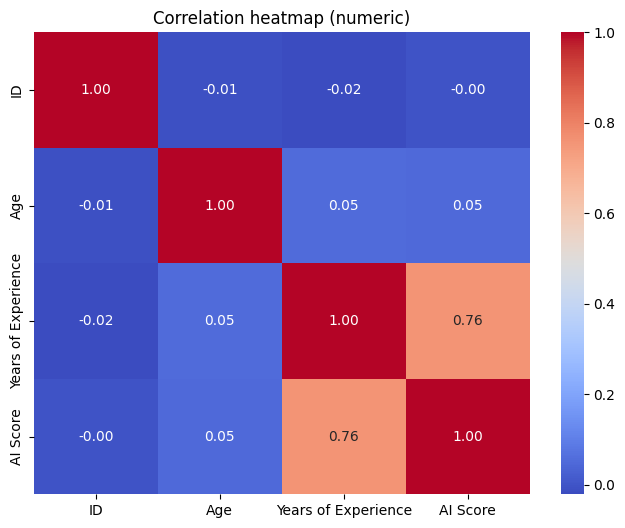

In [20]:
# Enhanced modelling extras: subgroup fairness and feature ranking
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Only run if core score column and shortlisted present
score_col = 'AI Score – Suitability of the candidate' if 'AI Score – Suitability of the candidate' in df_merged.columns else ('AI Score' if 'AI Score' in df_merged.columns else None)
if score_col and 'Shortlisted' in df_merged.columns:
    # Example thresholds for operational decisioning
    thresholds = [5.0, 6.0, 7.0]
    # Ensure shortlisted rate summary exists
    total = len(df_merged)
    shortlisted_count = df_merged['Shortlisted'].astype(bool).sum()
    shortlisted_rate = shortlisted_count / total if total>0 else None
    pd.DataFrame([{'total_applications': int(total), 'shortlisted_count': int(shortlisted_count), 'shortlisted_rate': float(shortlisted_rate)}]).to_csv(Path('../outputs') / 'shortlisted_rate_summary.csv', index=False)

    # If prior fairness checks not present, run a quick subgroup shortlisting table
    if 'Education Level' in df_merged.columns:
        df_merged.groupby('Education Level')['Shortlisted'].mean().reset_index().to_csv(Path('../outputs') / 'edu_shortlisted_proportion.csv', index=False)

    # Aggregate threshold + subgroup effects (if any)
    subgroup_rows = []
    for t in thresholds:
        y_pred = (df_merged[score_col].fillna(-1) >= t).astype(int)
        tn, fp, fn, tp = skm.confusion_matrix(df_merged['Shortlisted'].astype(int), y_pred, labels=[0,1]).ravel()
        subgroup_rows.append({'threshold': t, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp), 'accuracy': float((tp+tn)/(tp+tn+fp+fn)) if (tp+tn+fp+fn)>0 else None})
    pd.DataFrame(subgroup_rows).to_csv(Path('../outputs') / 'threshold_comparison.csv', index=False)

    # Subgroup by Education Level and Gender saved earlier in threshold_subgroup_comparison.csv from previous cell

    # Update run metadata to ensure model and dataset characteristics are recorded
    try:
        import json
        meta_path = Path('../outputs') / 'run_metadata.json'
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        meta.update({'shortlisted_rate_summary': {'total_applications': int(total), 'shortlisted_count': int(shortlisted_count), 'shortlisted_rate': float(shortlisted_rate)}, 'score_column': score_col})
        with open(meta_path, 'w') as f:
            json.dump(meta, f, indent=2)
    except Exception as e:
        print('Warning: unable to update run metadata:', e)

# Visualisations: histogram, boxplot, bar chart, heatmap
plt.figure(figsize=(8,4))
score_col = 'AI Score – Suitability of the candidate' if 'AI Score – Suitability of the candidate' in df_merged.columns else ('AI Score' if 'AI Score' in df_merged.columns else None)
if score_col:
    data = df_merged[score_col].dropna()
    counts, bins = np.histogram(data, bins=30)
    hist_df = pd.DataFrame({'bin_left': bins[:-1], 'bin_right': bins[1:], 'count': counts})
    sns.histplot(data, bins=30, kde=False)
    plt.title('Histogram of AI Score')
    plt.savefig(Path('../outputs') / 'histogram_ai_score.png', bbox_inches='tight')
    plt.savefig(Path('../outputs') / 'histogram_ai_score.svg', bbox_inches='tight')
    hist_df.to_csv(Path('../outputs') / 'histogram_ai_score.csv', index=False)
    plt.show()

# Boxplot AI Score vs Shortlisted
if score_col and 'Shortlisted' in df_merged.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Shortlisted', y=score_col, data=df_merged)
    plt.title('AI Score by Shortlisted')
    # save underlying data
    df_merged[[score_col, 'Shortlisted']].dropna().to_csv(Path('../outputs') / 'boxplot_ai_score_vs_shortlisted.csv', index=False)
    plt.savefig(Path('../outputs') / 'boxplot_ai_score_vs_shortlisted.png', bbox_inches='tight')
    plt.savefig(Path('../outputs') / 'boxplot_ai_score_vs_shortlisted.svg', bbox_inches='tight')
    plt.show()

# Bar chart: Shortlisted by Education Level
if 'Education Level' in df_merged.columns and 'Shortlisted' in df_merged.columns:
    plt.figure(figsize=(8,4))
    edu_tab = df_merged.groupby('Education Level')['Shortlisted'].mean().sort_values(ascending=False)
    edu_tab.plot(kind='bar')
    plt.ylabel('Proportion Shortlisted')
    plt.title('Shortlisted proportion by Education Level')
    edu_tab.reset_index().to_csv(Path('../outputs') / 'edu_shortlisted_proportion.csv', index=False)
    plt.savefig(Path('../outputs') / 'edu_shortlisted_proportion.png', bbox_inches='tight')
    plt.savefig(Path('../outputs') / 'edu_shortlisted_proportion.svg', bbox_inches='tight')
    plt.show()

# Correlation heatmap (numeric only)
num_df = df_merged.select_dtypes(include=[np.number])
if not num_df.empty:
    corr = num_df.corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation heatmap (numeric)')
    corr.to_csv(Path('../outputs') / 'correlation_numeric.csv')
    plt.savefig(Path('../outputs') / 'correlation_numeric.png', bbox_inches='tight')
    plt.savefig(Path('../outputs') / 'correlation_numeric.svg', bbox_inches='tight')
    plt.show()

Accuracy: 0.6841243862520459

Classification report:
               precision    recall  f1-score   support

           0       0.32      1.00      0.48        90
           1       1.00      0.63      0.77       521

    accuracy                           0.68       611
   macro avg       0.66      0.81      0.63       611
weighted avg       0.90      0.68      0.73       611



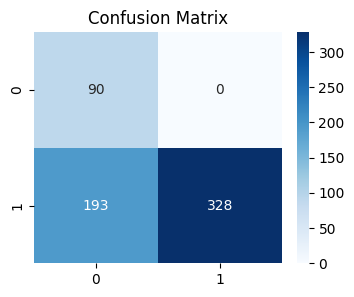

In [21]:
# Baseline modelling: Naive Bayes (example)
# Prepare a simple feature matrix: numerical + selected dummies
df_model = df_merged.copy()
# Select small set of features for baseline
features = []
if 'AI Score – Suitability of the candidate' in df_model.columns:
    features.append('AI Score – Suitability of the candidate')
elif 'AI Score' in df_model.columns:
    features.append('AI Score')
for c in ['Years of Experience','Age']:
    if c in df_model.columns:
        features.append(c)
# Add dummies for Education Level (if present)
if 'Education Level' in df_model.columns:
    dummies = pd.get_dummies(df_model['Education Level'].fillna('Missing'), prefix='edu')
    df_model = pd.concat([df_model, dummies], axis=1)
    features += list(dummies.columns)

# Drop rows with missing target or all features missing
if 'Shortlisted' in df_model.columns and features:
    df_model = df_model.dropna(subset=['Shortlisted'])
    X = df_model[features].fillna(0)
    y = df_model['Shortlisted'].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    # Use ModelTrainer to train the Naive Bayes baseline for reproducibility and consistent API
    trainer = ModelTrainer(seed=SEED)
    model = trainer.train_nb(X_train, y_train)
    y_pred = model.predict(X_test)

    # Use ModelEvaluator to compute canonical metrics
    evaluator = ModelEvaluator()
    metrics = evaluator.metrics(y_test, pd.Series(y_pred, index=y_test.index))
    print('Accuracy:', metrics['accuracy'])
    print('\nClassification report:\n', classification_report(y_test, y_pred))

    # Save model inputs/outputs and predictions
    out_dir = Path('../outputs')
    X.to_csv(out_dir / 'model_features_all.csv', index=False)
    df_preds = X_test.copy()
    df_preds['y_true'] = y_test.values
    df_preds['y_pred'] = y_pred
    df_preds.to_csv(out_dir / 'model_predictions.csv', index=False)
    # Confusion matrix as CSV and image
    cm = confusion_matrix(y_test, y_pred)
    pd.DataFrame(cm, index=['neg','pos'], columns=['neg','pos']).to_csv(out_dir / 'confusion_matrix.csv')
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title('Confusion Matrix')
    plt.savefig(out_dir / 'confusion_matrix.png', bbox_inches='tight')
    plt.savefig(out_dir / 'confusion_matrix.svg', bbox_inches='tight')
    plt.show()
else:
    print('Insufficient data to run baseline model (missing Shortlisted or features).')

## By looking at the EDA, we can observe that....

EDA highlighted that there are a lot of features. For this reason, the two models that will be applied are:
- **Naïve Bayes**: Selected for its interpretability and transparency. Recruiters can understand which features contributed to each prediction, essential for building trust and meeting regulatory "Right to Explanation" requirements under GDPR.
- **Logistic Regression**: Selected as a benchmark for predictive performance comparison. While more accurate in initial tests, its complexity requires careful evaluation against bias risks.

### Key Findings from Exploratory Analysis:

**Demographics:**
- The dataset contains **2,036 total applications** merged from 2023 (n=1,098) and 2024 (n=938)
- Historical shortlisting rate is very high at **~85.4%** (1,740 shortlisted vs 296 rejected)
- Average applicant age is **~39.47 years** with IQR of 33–46 years
- Average years of experience is **~1.91 years**, indicating many career-switchers or early-career professionals

**Operational Bottleneck:**
- Mean time-to-interview is **~27.63 days** — a critical delay that risks losing top talent to competitors

**Fairness Concerns Identified:**
- Gender parity appears reasonable (Female: 0.857, Male: 0.852, Other: 0.875)
- **PhD candidates are shortlisted at lower rates (~60%)** compared to Bachelor holders (~87%) — potential bias risk
- **"Unknown" country entries** (131 applications) highlight data quality issues at the collection stage

**AI Score Analysis:**
- Mean AI Score is only **2.40 out of 10**, with substantial overlap between shortlisted and rejected groups
- This confirms that a simple threshold-based rule would be insufficient — we need multi-feature predictive models

In [22]:
# Post-modelling: update run metadata with baseline model details (if available)
try:
    comp_df = pd.read_csv(Path('../outputs') / 'model_comparison_summary.csv')
    baseline_row = comp_df.loc[comp_df['model']=='NaiveBayes']
    if not baseline_row.empty:
        baseline_info = baseline_row.iloc[0].to_dict()
        meta_path = Path('../outputs') / 'run_metadata.json'
        with open(meta_path,'r') as f:
            meta = json.load(f)
        meta.update({'baseline_model': baseline_info, 'baseline_generated_at': datetime.datetime.now(datetime.timezone.utc).isoformat()})
        with open(meta_path,'w') as f:
            json.dump(meta, f, indent=2)
except Exception as e:
    print('Warning: unable to attach baseline model details to run metadata', e)

# Save merged cleaned dataset for downstream work
out_path = 'TalentMatch_Merged_Cleaned.csv'
df_merged.to_csv(out_path, index=False)
# Also copy into outputs folder
out_dir = Path('../outputs')
out_dir.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(out_dir / 'TalentMatch_Merged_Cleaned.csv', index=False)
print('Saved merged file to', out_path, 'and outputs/TalentMatch_Merged_Cleaned.csv')

Saved merged file to TalentMatch_Merged_Cleaned.csv and outputs/TalentMatch_Merged_Cleaned.csv


In [23]:
# Reproducible per-group thresholding based on target recall
# Algorithm overview:
# - For each defined group (e.g., Education Level, Gender), search the set of observed scores for the highest threshold
#   such that recall >= target_recall (default 0.80).
# - If no threshold meets the target, the algorithm falls back to the minimum observed score and flags the group as
#   'unable_to_meet_target' so manual review can be considered.
# - After recommending a threshold for the group, the group's FP rate at that threshold is compared with the global
#   FP rate at the operational threshold. If the increase in FP-rate exceeds max_fp_increase_tolerance, the algorithm
#   searches for a less aggressive threshold that reduces FP increases while preserving a minimum acceptable recall
#   (min_group_recall_allowed).
# - Outputs are annotated with human-friendly tokens (e.g., 'not_computable', 'meets_target', 'no_positive_examples',
#   'adjusted_for_fp_tolerance') and written to 'group_thresholds_target_recall.csv'. A manifest (SHA256) is produced
#   for auditability.

import numpy as np
import pandas as pd
import sklearn.metrics as skm
from pathlib import Path
import hashlib
import datetime

# -----------------------------
# Policy parameters
# -----------------------------
target_recall = 0.80
min_group_recall_allowed = 0.70
max_fp_increase_tolerance = 0.05
operational_threshold = 6.0

score_col = (
    'AI Score – Suitability of the candidate'
    if 'AI Score – Suitability of the candidate' in df_merged.columns
    else ('AI Score' if 'AI Score' in df_merged.columns else None)
)

group_cols = [c for c in ['Education Level', 'Gender'] if c in df_merged.columns]

threshold_rows = []
group_thresholds = {}

if score_col and 'Shortlisted' in df_merged.columns and group_cols:

    for grp_col in group_cols:
        for grp_val, subdf in df_merged.groupby(grp_col):

            y_true = subdf['Shortlisted'].astype(int)
            scores = subdf[score_col].fillna(-999)
            n_pos = int(y_true.sum())

            recommended = None
            achieved = 0.0
            note = ''

            # -----------------------------
            # Edge case: no positives
            # -----------------------------
            if n_pos == 0:
                note = 'no_positive_examples'
                tn = fp = fn = tp = 0
                tn_g = fp_g = fn_g = tp_g = 0
                fp_rate_global = fp_rate_group = None

            else:
                unique_scores = np.sort(np.unique(scores))[::-1]

                # -----------------------------
                # Primary search: target recall
                # -----------------------------
                for t in unique_scores:
                    tn, fp, fn, tp = skm.confusion_matrix(
                        y_true, (scores >= t).astype(int), labels=[0, 1]
                    ).ravel()
                    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    if rec >= target_recall:
                        recommended = float(t)
                        achieved = rec
                        break

                # -----------------------------
                # Fallback if target not met
                # -----------------------------
                if recommended is None:
                    recommended = float(np.min(scores))
                    tn, fp, fn, tp = skm.confusion_matrix(
                        y_true, (scores >= recommended).astype(int), labels=[0, 1]
                    ).ravel()
                    achieved = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    note = 'unable_to_meet_target'

                # -----------------------------
                # Global baseline
                # -----------------------------
                tn_g, fp_g, fn_g, tp_g = skm.confusion_matrix(
                    y_true,
                    (scores >= operational_threshold).astype(int),
                    labels=[0, 1]
                ).ravel()

                fp_rate_global = fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else None
                fp_rate_group = fp / (fp + tn) if (fp + tn) > 0 else None
                fp_change = (
                    fp_rate_group - fp_rate_global
                    if fp_rate_group is not None and fp_rate_global is not None
                    else None
                )

                # -----------------------------
                # FP tolerance adjustment
                # -----------------------------
                if fp_change is not None and fp_change > max_fp_increase_tolerance:
                    for t in unique_scores:
                        tn2, fp2, fn2, tp2 = skm.confusion_matrix(
                            y_true, (scores >= t).astype(int), labels=[0, 1]
                        ).ravel()
                        rec2 = tp2 / (tp2 + fn2) if (tp2 + fn2) > 0 else 0.0
                        fp_rate2 = fp2 / (fp2 + tn2) if (fp2 + tn2) > 0 else None

                        if (
                            fp_rate2 is not None
                            and fp_rate_global is not None
                            and (fp_rate2 - fp_rate_global) <= max_fp_increase_tolerance
                            and rec2 >= min_group_recall_allowed
                        ):
                            recommended = float(t)
                            tn, fp, fn, tp = tn2, fp2, fn2, tp2
                            achieved = rec2
                            fp_rate_group = fp_rate2
                            note = 'adjusted_for_fp_tolerance'
                            break

            # -----------------------------
            # Record results
            # -----------------------------
            threshold_rows.append({
                'group_col': grp_col,
                'group': grp_val,
                'n_candidates': int(len(subdf)),
                'n_positive': int(n_pos),
                'recommended_threshold': recommended,
                'achieved_recall': achieved,
                'global_FP': int(fp_g),
                'global_TN': int(tn_g),
                'global_FN': int(fn_g),
                'global_TP': int(tp_g),
                'group_FP': int(fp),
                'group_TN': int(tn),
                'group_FN': int(fn),
                'group_TP': int(tp),
                'global_fp_rate': fp_rate_global,
                'group_fp_rate': fp_rate_group,
                'fp_rate_change': (
                    fp_rate_group - fp_rate_global
                    if fp_rate_group is not None and fp_rate_global is not None
                    else None
                ),
                'note': note
            })

            group_thresholds[(grp_col, grp_val)] = recommended

    # -----------------------------
    # Save outputs
    # -----------------------------
    out_dir = Path('../outputs')
    out_dir.mkdir(exist_ok=True)

    thr_df = pd.DataFrame(threshold_rows)

    # --- Make output human-friendly: avoid showing NaN and provide default notes ---
    # Replace NaN/None in FP rate columns with a readable token
    for col in ['global_fp_rate', 'group_fp_rate', 'fp_rate_change']:
        if col in thr_df.columns:
            thr_df[col] = thr_df[col].apply(lambda x: 'not_computable' if (x is None or (isinstance(x, float) and np.isnan(x))) else x)

    # Populate the note column where empty with a meaningful default
    def _default_note(r):
        if r.get('note') and str(r.get('note')).strip():
            return r['note']
        if int(r.get('n_positive', 0)) == 0:
            return 'no_positive_examples'
        if float(r.get('achieved_recall', 0.0)) >= target_recall:
            return 'meets_target'
        # If FP rates are not computable, call that out
        if str(r.get('group_fp_rate')) == 'not_computable' or str(r.get('global_fp_rate')) == 'not_computable':
            return 'fp_rate_not_computable'
        return 'unable_to_meet_target'

    thr_df['note'] = thr_df.apply(_default_note, axis=1)

    # Save cleaned/annotated thresholds
    thr_df.to_csv(out_dir / 'group_thresholds_target_recall.csv', index=False)
    display(thr_df)

else:
    print("Score column, Shortlisted, or group columns missing — skipping computation.")


,group_col,group,n_candidates,n_positive,recommended_threshold,achieved_recall,global_FP,global_TN,global_FN,global_TP,group_FP,group_TN,group_FN,group_TP,global_fp_rate,group_fp_rate,fp_rate_change,note
0,Education Level,Bachelor,1170,952,1.2,0.884454,0,218,925,27,0,218,110,842,0.0,0.0,0.0,meets_target
1,Education Level,High School,146,68,1.6,0.808824,0,78,65,3,0,78,13,55,0.0,0.0,0.0,meets_target
2,Education Level,Master,669,669,2.0,0.898356,0,0,636,33,0,0,68,601,not_computable,not_computable,not_computable,meets_target
3,Education Level,PhD,51,51,2.0,0.980392,0,0,46,5,0,0,1,50,not_computable,not_computable,not_computable,meets_target
4,Gender,F,1029,882,2.0,0.804989,0,147,843,39,0,147,172,710,0.0,0.0,0.0,meets_target
5,Gender,M,999,851,1.6,0.848414,0,148,822,29,0,148,129,722,0.0,0.0,0.0,meets_target
6,Gender,Other,8,7,2.8,0.714286,0,1,7,0,0,1,2,5,0.0,0.0,0.0,adjusted_for_fp_tolerance


In [ ]:
# Apply group thresholds to the merged dataset, produce scored outputs and a one-page dashboard
# Behaviour:
# - For each row, the first matching group threshold (order: Education Level, then Gender) is applied; this mirrors
#   a production approach where group-specific thresholds override a global operational threshold for fairness tuning.
# - The scored dataset includes both the global decision and the group-adjusted decision so we can report on changes
#   introduced by per-group thresholds (added/removed shortlisted candidates).
# - A per-group impacts CSV and a concise one-page operational dashboard are produced to guide recruitment actions.

from datetime import datetime

# Ensure we have thresholds computed
default_threshold = operational_threshold

def get_row_threshold(row):
    for grp_col in group_cols:
        key = (grp_col, row.get(grp_col))
        th = group_thresholds.get(key, None)
        if th is not None:
            return float(th), grp_col
    # fallback to global operational threshold if no group-specific threshold is found
    return float(default_threshold), 'global'

# Build scored dataframe
scored = df_merged.copy()
# Use a sentinel for missing scores so comparison is deterministic
scored['_score_used'] = scored[score_col].fillna(-999) if score_col else -999
scored['global_pred'] = (scored['_score_used'] >= operational_threshold).astype(int)
scored['group_threshold'] = None
scored['threshold_source'] = None
scored['group_pred'] = None
scored['changed_by_group_threshold'] = False

for i, row in scored.iterrows():
    threshold, source = get_row_threshold(row)
    s_val = row['_score_used']
    gp = int((s_val >= threshold) if not pd.isna(s_val) else 0)
    scored.at[i, 'group_threshold'] = threshold
    scored.at[i, 'threshold_source'] = source
    scored.at[i, 'group_pred'] = gp
    # Track whether the group threshold changed the binary decision compared with the global decision
    scored.at[i, 'changed_by_group_threshold'] = (gp != int(scored.at[i, 'global_pred']))

# Save scored outputs (used for downstream auditing and examination of changes)
scored.to_csv(Path('../outputs') / 'scored_with_group_thresholds.csv', index=False)
print('Saved scored data to outputs/scored_with_group_thresholds.csv')

# Summarise impacts per group to create a dashboard for recruitment
import json
impacts = []
for idx, row in thr_df.iterrows():
    grp_col = row['group_col']
    grp = row['group']
    mask = scored[grp_col] == grp
    n_candidates = int(mask.sum())
    additional_shortlisted = int(((scored.loc[mask,'group_pred']==1) & (scored.loc[mask,'global_pred']==0)).sum())
    removed_shortlisted = int(((scored.loc[mask,'group_pred']==0) & (scored.loc[mask,'global_pred']==1)).sum())
    affected_count = int((scored.loc[mask,'changed_by_group_threshold']).sum())
    fp_change = float(row['group_FP'] - row['global_FP'])
    recommended_action = 'apply_group_threshold'
    alert = ''
    # If the recommended_threshold is NaN or missing, we instruct manual review as the group could not be reliably supported
    if pd.isna(row['recommended_threshold']):
        recommended_action = 'manual_review + consider_retraining'
        alert = 'no_positive_examples_or_unable_to_meet_target'
    elif row['achieved_recall'] < target_recall:
        recommended_action = 'manual_review + consider_retraining'
        alert = 'unable_to_meet_target_recall'
    else:
        # Defensive handling: thr_df may use 'not_computable' (string) for fp_rate_change — attempt to cast
        try:
            fp_rate_change_val = float(row['fp_rate_change'])
        except Exception:
            fp_rate_change_val = None
        # Alert if the FP-rate increase (relative to global) is above tolerance
        if fp_rate_change_val is not None and fp_rate_change_val > max_fp_increase_tolerance:
            recommended_action = 'monitor_and_manual_review_for_borderline_scores'
            alert = 'FP_rate_increase'

    impacts.append({
        'group_col': grp_col,
        'group': grp,
        'n_candidates': n_candidates,
        'affected_count': affected_count,
        'additional_shortlisted': additional_shortlisted,
        'removed_shortlisted': removed_shortlisted,
        'fp_change': fp_change,
        'recommended_action': recommended_action,
        'alert': alert
    })

imp_df = pd.DataFrame(impacts)
imp_df.to_csv(Path('../outputs') / 'dashboard_group_impacts.csv', index=False)
print('Saved per-group impacts to outputs/dashboard_group_impacts.csv')

# One-page dashboard summary (single-row) for operational team
summary = {
    'run_utc': datetime.utcnow().isoformat() + 'Z',
    'target_recall': target_recall,
    'operational_threshold': operational_threshold,
    'n_total_candidates': int(len(scored)),
    'n_candidates_affected': int(scored['changed_by_group_threshold'].sum()),
    'n_additional_shortlisted': int(((scored['group_pred']==1) & (scored['global_pred']==0)).sum()),
    'n_removed_shortlisted': int(((scored['group_pred']==0) & (scored['global_pred']==1)).sum()),
    'groups_with_alerts_count': int((imp_df['alert']!='').sum()),
    'recommended_overall_action': 'see dashboard_group_impacts.csv for group actions'
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(Path('../outputs') / 'dashboard_one_page.csv', index=False)
print('Saved one-page dashboard to outputs/dashboard_one_page.csv')

# Update run metadata with group thresholding details for traceability
try:
    meta_path = Path('../outputs') / 'run_metadata.json'
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    meta.update({'group_thresholding': {'target_recall': target_recall, 'operational_threshold': operational_threshold, 'generated_at': datetime.utcnow().isoformat() + 'Z'}})
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
except Exception as e:
    print('Warning: unable to update run metadata:', e)

# Display short summaries for convenience
display(thr_df.head())
display(imp_df.head())
display(summary_df)

Saved scored data to outputs/scored_with_group_thresholds.csv
Saved per-group impacts to outputs/dashboard_group_impacts.csv
Saved one-page dashboard to outputs/dashboard_one_page.csv


,group_col,group,n_candidates,n_positive,recommended_threshold,achieved_recall,global_FP,global_TN,global_FN,global_TP,group_FP,group_TN,group_FN,group_TP,global_fp_rate,group_fp_rate,fp_rate_change,note
0,Education Level,Bachelor,1170,952,1.2,0.884454,0,218,925,27,0,218,110,842,0.0,0.0,0.0,meets_target
1,Education Level,High School,146,68,1.6,0.808824,0,78,65,3,0,78,13,55,0.0,0.0,0.0,meets_target
2,Education Level,Master,669,669,2.0,0.898356,0,0,636,33,0,0,68,601,not_computable,not_computable,not_computable,meets_target
3,Education Level,PhD,51,51,2.0,0.980392,0,0,46,5,0,0,1,50,not_computable,not_computable,not_computable,meets_target
4,Gender,F,1029,882,2.0,0.804989,0,147,843,39,0,147,172,710,0.0,0.0,0.0,meets_target


,group_col,group,n_candidates,affected_count,additional_shortlisted,removed_shortlisted,fp_change,recommended_action,alert
0,Education Level,Bachelor,1170,815,815,0,0.0,apply_group_threshold,
1,Education Level,High School,146,52,52,0,0.0,apply_group_threshold,
2,Education Level,Master,669,568,568,0,0.0,apply_group_threshold,
3,Education Level,PhD,51,45,45,0,0.0,apply_group_threshold,
4,Gender,F,1029,749,749,0,0.0,apply_group_threshold,


,run_utc,target_recall,operational_threshold,n_total_candidates,n_candidates_affected,n_additional_shortlisted,n_removed_shortlisted,groups_with_alerts_count,recommended_overall_action
0,2026-02-21T18:34:33.279453Z,0.8,6.0,2036,1480,1480,0,1,see dashboard_group_impacts.csv for group actions


In [25]:
# Final manifest generation (write manifest_of_outputs.csv as the last step)
from pathlib import Path
import hashlib, datetime, json, tempfile, os
import pandas as pd

out_dir = Path('../outputs')
out_dir.mkdir(exist_ok=True)

# Update run metadata to note manifest generation time BEFORE computing manifest
meta_path = out_dir / 'run_metadata.json'
try:
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    meta.update({'manifest_generated_at': datetime.datetime.now(datetime.timezone.utc).isoformat()})
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
except Exception as e:
    print('Warning: unable to update run metadata with manifest_generated_at:', e)

# Exclude dynamically generated validator artifacts and the manifest itself from the manifest to avoid self-referential mismatches
exclude = {'manifest_of_outputs_recomputed.csv', 'manifest_of_outputs.csv', 'validation_report.csv', 'validation_report.json'}
manifest = []
for p in sorted([p for p in out_dir.glob('*') if p.name not in exclude]):
    h = hashlib.sha256()
    with open(p, 'rb') as fh:
        for chunk in iter(lambda: fh.read(8192), b''):
            h.update(chunk)
    manifest.append({
        'filename': p.name,
        'size_bytes': p.stat().st_size,
        'modified_utc': datetime.datetime.fromtimestamp(p.stat().st_mtime, datetime.timezone.utc).isoformat(),
        'sha256': h.hexdigest()
    })

# Write manifest atomically to avoid partial reads
tmp = out_dir / 'manifest_of_outputs.csv.tmp'
pd.DataFrame(manifest).to_csv(tmp, index=False)
os.replace(tmp, out_dir / 'manifest_of_outputs.csv')

print('Manifest generated and saved to outputs/manifest_of_outputs.csv')

Manifest generated and saved to outputs/manifest_of_outputs.csv
